## Imputation of time-series

Some of the code was found here for visualisation: https://cienciadedatos.net/documentos/py46-forecasting-time-series-missing-values

In [1]:
!nvidia-smi

Sat Apr 18 15:21:59 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.126.20             Driver Version: 580.126.20     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 5090        On  |   00000000:02:00.0 Off |                  N/A |
|  0%   40C    P8             30W /  575W |       2MiB /  32607MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
# Imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from unidecode import unidecode
import math
import torch
import torch.nn as nn

import argparse
import torch
import datetime
import json
import yaml
import os

import sys

sys.path.append(".")
sys.path.append("./models")

from models.unet_main_model import Unet_WaterQual
from utils import *

import matplotlib.pyplot as plt


In [3]:
color = '\033[1m\033[38;5;208m' 
print(f"{color}Version numpy: {np.__version__}")
print(f"{color}Version pytorch: {torch.__version__}")

Version numpy: 2.1.2
Version pytorch: 2.8.0+cu128


### Load Data

In [4]:
from dataset_ope import get_dataloader
gpu = torch.device("cuda" if torch.cuda.is_available() else "cpu")
train_loader, valid_loader, test_loader, scaler, mean_scaler = get_dataloader(device=gpu, batch_size=8)

Loaded SAGD training data with shape:  (25981, 75)
Loaded SAGD training mask with shape:  (25981, 75)
Loaded covariates with shape:  (25981, 72)
Training dataset len:  4279
Loaded SAGD training data with shape:  (25981, 75)
Loaded SAGD training mask with shape:  (25981, 75)
Loaded covariates with shape:  (25981, 72)
Valid dataset len:  20
Loaded SAGD training data with shape:  (25981, 75)
Loaded SAGD training mask with shape:  (25981, 75)
Loaded covariates with shape:  (25981, 72)
Test dataset len:  28


In [5]:
data_dim = 75

## Model Definition and Training

In [6]:
# Load the config

# My own config for cigeo
path = "./config/unet_config.yaml"

with open(path, "r") as f:
    config = yaml.safe_load(f)

# The only thing I overwrite, so I can change epochs for my tests
# EPOCHS
config["train"]["epochs"] = 100

current_time = datetime.datetime.now().strftime("%Y%m%d_%H%M%S") 
foldername = (
    "./save/validationindex" + "_" + current_time
)

os.makedirs(foldername, exist_ok=True)
with open(foldername + "config.json", "w") as f:
    json.dump(config, f, indent=4)


In [7]:
do_train = True

device = torch.device("cuda")
model = Unet_WaterQual(config, "cuda:0", target_dim=data_dim).to("cuda:0")

if do_train:
# define and train mode. keep an history for monitoring
    history = {}
    # Run on GPU

    # It returns history, which we don't need really
    _ = train(
        model,
        config["train"],
        train_loader,
        valid_loader=valid_loader,
        foldername=foldername,
        lr=1e-5,
        history=history)

100%|██████████| 3/3 [00:00<00:00, 668.24it/s, valid_avg_epoch_loss=0.161, epoch=19]



 best loss is updated to  0.1609809324145317 at 19


100%|██████████| 3/3 [00:00<00:00, 918.26it/s, valid_avg_epoch_loss=0.144, epoch=59]



 best loss is updated to  0.14426625985652208 at 59


100%|██████████| 3/3 [00:00<00:00, 1040.00it/s, valid_avg_epoch_loss=0.101, epoch=79]



 best loss is updated to  0.10126844172676404 at 79


100%|██████████| 3/3 [00:00<00:00, 821.66it/s, valid_avg_epoch_loss=0.249, epoch=99]


In [8]:
if do_train:
    torch.save(model.diffmodel.state_dict(), "./saved_weights/unet_model_weights_unet.pt")
    torch.save(model.state_dict(), "./saved_weights/unet_model_weights.pt")
else:
    model.load_state_dict(torch.load("./saved_weights/unet_model_weights.pt", weights_only=True))
    model.to(device)


In [9]:
param_size = 0
for param in model.parameters():
    param_size += param.nelement() * param.element_size()
buffer_size = 0
for buffer in model.buffers():
    buffer_size += buffer.nelement() * buffer.element_size()

size_all_mb = (param_size + buffer_size) / 1024**2
print('model size: {:.3f}MB'.format(size_all_mb))


model size: 0.794MB


## Tests

In [10]:
train_loader, valid_loader, test_loader, scaler, mean_scaler = get_dataloader(device=gpu, batch_size=8)

Loaded SAGD training data with shape:  (25981, 75)
Loaded SAGD training mask with shape:  (25981, 75)
Loaded covariates with shape:  (25981, 72)
Training dataset len:  4279
Loaded SAGD training data with shape:  (25981, 75)
Loaded SAGD training mask with shape:  (25981, 75)
Loaded covariates with shape:  (25981, 72)
Valid dataset len:  20
Loaded SAGD training data with shape:  (25981, 75)
Loaded SAGD training mask with shape:  (25981, 75)
Loaded covariates with shape:  (25981, 72)
Test dataset len:  28


In [11]:
for batch in test_loader:
    observed_mask_forecast = batch['observed_mask']
    # set later half to 0
    print(observed_mask_forecast.shape)
    observed_mask_forecast[:, 25:] = 0
    


    observed_data = batch['observed_data']
    observed_data = observed_data * observed_mask_forecast

    observed_mask_forecast = observed_mask_forecast.to(model.device).float()
    observed_data = observed_data.to(model.device).float()
    
    with torch.no_grad():
        generated = model.impute(observed_data, observed_mask_forecast, n_samples=1, timestamps=batch['timepoints'])
        break

torch.Size([8, 24, 75])


In [12]:
generated_test = generated.cpu().permute([0, 1, 3, 2]).numpy()[0].squeeze()
observations = observed_data[0].squeeze().cpu().numpy()
mask = observed_mask_forecast[0].squeeze().cpu().numpy()
timestamps = batch['timepoints'][0].squeeze().numpy()

In [13]:
generated_test.shape, observations.shape, mask.shape, timestamps.shape

((24, 75), (24, 75), (24, 75), (24,))

### Single generation test

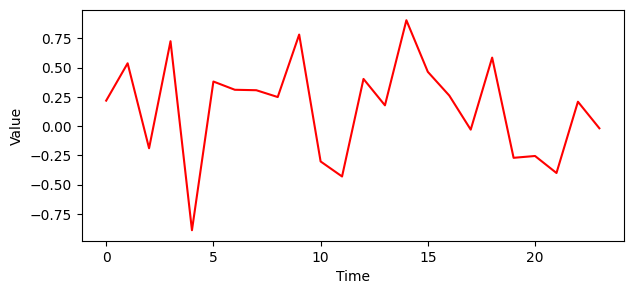

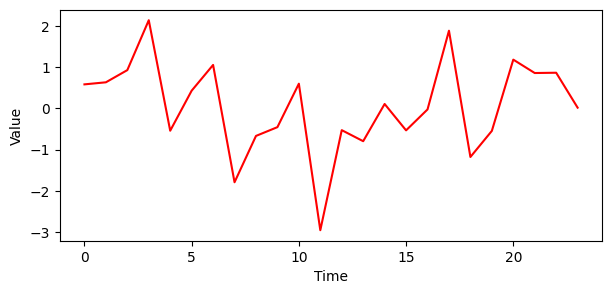

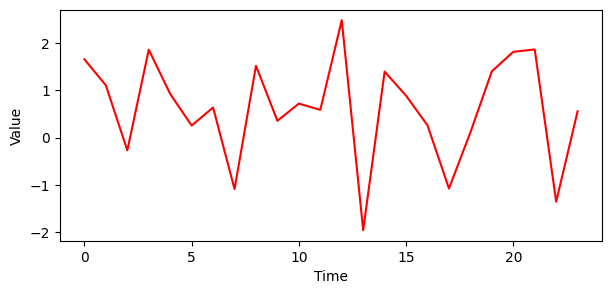

In [14]:
def find_gaps(serie_training_mask):
    """
    Return the indices of the gaps in values based on the training mask.
    """

    padded_mask = np.pad(np.logical_not(serie_training_mask).astype(int), (1,1), mode='constant', constant_values=0)

    gaps_start = np.where(np.diff(padded_mask) == 1)[0]
    gaps_end = np.where(np.diff(padded_mask) == -1)[0]

    gaps = np.array(list(zip(gaps_start, gaps_end)))

    return gaps

# Print gap filling

for i in range(3):
    fig, ax = plt.subplots(figsize=(7, 3))

    gen_squeezed = generated_test.squeeze()
    mask_squeezed = mask.squeeze()


    gaps = find_gaps(1 - mask_squeezed[:, i])
    for gap in gaps:
        if gap[1] <= len(gen_squeezed[:, i]) and gap[0] >= 0:
            ax.plot(
                np.linspace(gap[0], gap[1]-1, num=gap[1]-gap[0]),
                gen_squeezed[gap[0]:gap[1], i],
                color = 'blue',
                label = 'observations'
                )

    gaps = find_gaps(mask_squeezed[:, i])

    for gap in gaps:
        if gap[1] <= len(gen_squeezed[:, i]) and gap[0] >= 0:
            ax.plot(
                np.linspace(gap[0], gap[1]-1, num=gap[1]-gap[0]),
                gen_squeezed[gap[0]:gap[1], i],
                color = 'red',
                label = 'predictions'
                )
        
    #plt.title(test_station_name + " " +parameter_names[i])
    plt.xlabel('Time')
    plt.ylabel('Value')
    plt.plot()

### Evaluate forecasting

In [15]:
import numpy as np
from collections import defaultdict

horizons = [6, 12, 18]
n_trials = 5

results = {h: defaultdict(list) for h in horizons}

# Run trials
for trial in range(n_trials):
    print(f"Trial {trial+1}/{n_trials}")
    
    for h in horizons:
        out = evaluate_forecasting(
            model,
            test_loader,
            prediction_horizon=h,
            nsample=100,
            foldername=foldername
        )
        
        for key, value in out.items():
            results[h][key].append(value)

# Compute mean & std
print("\n=== Forecasting Results ===")
for h in horizons:
    print(f"\nHorizon: {h}")
    
    for metric in results[h]:
        values = np.array(results[h][metric])
        mean = values.mean()
        std = values.std()
        
        print(f"{metric}: {mean:.4f} ± {std:.4f}")

Trial 1/5


100%|██████████| 4/4 [00:21<00:00,  5.47s/it, rmse_total=1.02, mae_total=0.704, smape_total=121, batch_no=4] 


Trial 2/5


100%|██████████| 4/4 [00:22<00:00,  5.50s/it, rmse_total=1.02, mae_total=0.705, smape_total=121, batch_no=4] 


Trial 3/5


...

Trial 4/5


100%|██████████| 4/4 [00:21<00:00,  5.49s/it, rmse_total=1.02, mae_total=0.705, smape_total=122, batch_no=4] 


Trial 5/5


100%|██████████| 4/4 [00:22<00:00,  5.54s/it, rmse_total=1.02, mae_total=0.705, smape_total=122, batch_no=4] 



=== Forecasting Results ===

Horizon: 6
rmse: 0.9606 ± 0.0012
mae: 0.6716 ± 0.0010
smape: 116.9822 ± 0.4429
CRPS: 0.6058 ± 0.0009
CRPS_sum: 0.1841 ± 0.0003

Horizon: 12
rmse: 1.0037 ± 0.0006
mae: 0.6962 ± 0.0005
smape: 120.2760 ± 0.1908
CRPS: 0.6297 ± 0.0006
CRPS_sum: 0.3696 ± 0.0003

Horizon: 18
rmse: 1.0199 ± 0.0003
mae: 0.7050 ± 0.0004
smape: 121.3809 ± 0.1661
CRPS: 0.6379 ± 0.0003
CRPS_sum: 0.5588 ± 0.0003


In [16]:
rng = np.random.RandomState(1)

# generate one batch
for batch in test_loader:
    observed_mask = batch['observed_mask']
    # set later half to 0
    #print(observed_mask_forecast.shape)
    real_data = batch['observed_data']

    observed_mask_forecast = observed_mask.clone()
    observed_mask_forecast[:, 18:] = 0

    observed_data = batch['observed_data']
    observed_data = observed_data * observed_mask_forecast

    observed_mask_forecast = observed_mask_forecast.to(model.device).float()
    observed_data = observed_data.to(model.device).float()
    with torch.no_grad():
        generated = model.impute(observed_data, observed_mask_forecast, n_samples=100, timestamps=batch['timepoints'])
        break

In [17]:
generated_test = generated.permute([0, 1, 3, 2]).cpu()
X = np.arange(generated_test.shape[0]).reshape(-1, 1)

all_target_np = real_data
all_evalpoint_np = observed_mask.cpu() - observed_mask_forecast.cpu() #observed_mask_forecast.cpu() # with later points se tto 0
all_observed_np = observed_mask.cpu() # all points
all_given_np = observed_mask_forecast.cpu() # observations

K = generated_test.shape[-1] #feature
L = generated_test.shape[-2] #time length

In [18]:
def get_quantile(samples,q,dim=1):
    return torch.quantile(samples,q,axis=dim)

qlist =[0.05,0.25,0.5,0.75,0.95]
quantiles_imp= []
for q in qlist:
    quantiles_imp.append(get_quantile(generated_test, q, dim=1)*(1-all_given_np) + all_target_np * all_given_np)

print(quantiles_imp[0].shape)

torch.Size([8, 24, 75])


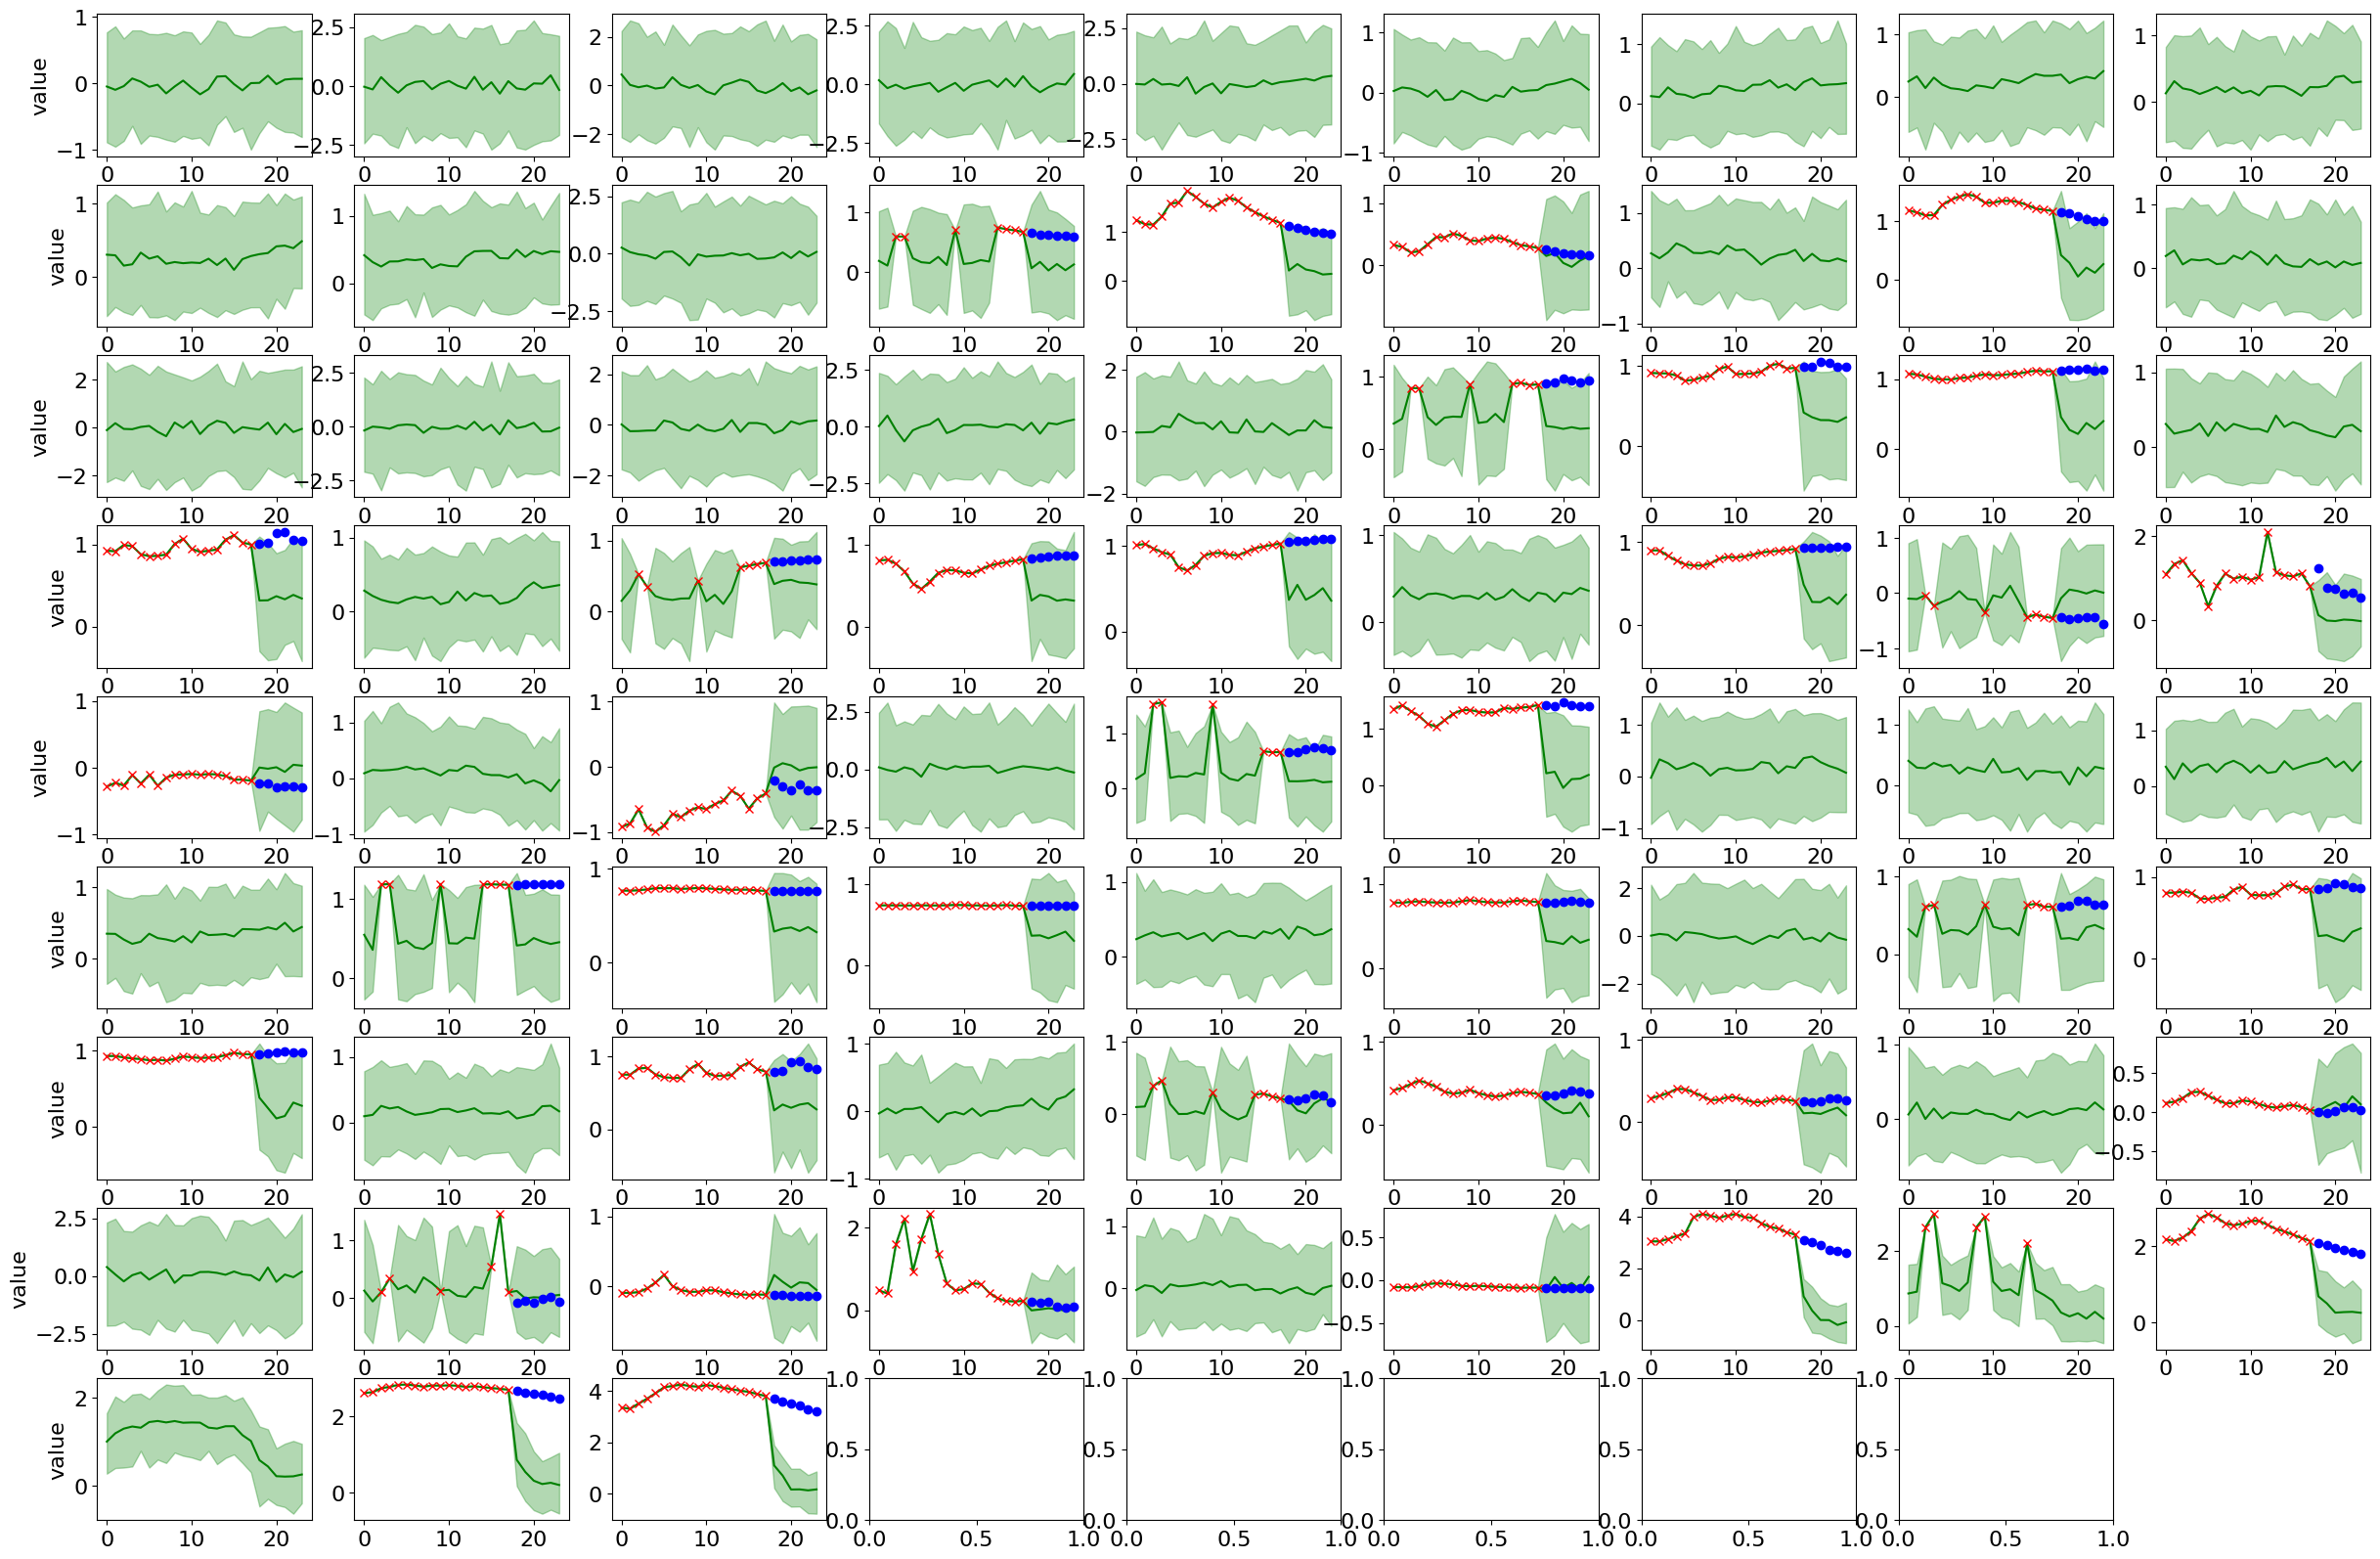

In [19]:
###airquality###
dataind = 4 #change to visualize a different sample

plt.rcParams["font.size"] = 16
fig, axes = plt.subplots(nrows=9, ncols=9,figsize=(30.0, 20.0))
fig.delaxes(axes[-1][-1])

for k in range(K):
    df = pd.DataFrame({"x":np.arange(0,L), "val":all_target_np[dataind,:,k], "y":all_evalpoint_np[dataind,:,k]})
    df = df[df.y != 0]
    df2 = pd.DataFrame({"x":np.arange(0,L), "val":all_target_np[dataind,:,k], "y":all_given_np[dataind,:,k]})
    df2 = df2[df2.y != 0]
    row = k // 9
    col = k % 9
    axes[row][col].plot(range(0,L), quantiles_imp[2][dataind,:,k], color = 'g',linestyle='solid',label='CSDI')
    axes[row][col].fill_between(range(0,L), quantiles_imp[0][dataind,:,k],quantiles_imp[4][dataind,:,k],
                    color='g', alpha=0.3)
    axes[row][col].plot(df.x,df.val, color = 'b',marker = 'o', linestyle='None')
    axes[row][col].plot(df2.x,df2.val, color = 'r',marker = 'x', linestyle='None')
    if col == 0:
        plt.setp(axes[row, 0], ylabel='value')
    if row == -1:
        plt.setp(axes[-1, col], xlabel='time')


### Evaluate Imputation

In [20]:
import numpy as np
from collections import defaultdict

ratios = [0.25, 0.50, 0.75, 0.90]
n_trials = 5

results = {r: defaultdict(list) for r in ratios}

# Run trials
for trial in range(n_trials):
    print(f"Trial {trial+1}/{n_trials}")
    
    for seed, r in enumerate(ratios):
        out = evaluate_imputation(
            model,
            test_loader,
            ratio_missing=r,
            nsample=100,
            seed=seed,
            foldername=foldername
        )
        
        for key, value in out.items():
            results[r][key].append(value)

# Compute mean & std
print("\n=== Imputation Results ===")
for r in ratios:
    print(f"\nMissing Ratio: {r}")
    
    for metric in results[r]:
        values = np.array(results[r][metric])
        mean = values.mean()
        std = values.std()
        
        print(f"{metric}: {mean:.4f} ± {std:.4f}")

Trial 1/5


100%|██████████| 4/4 [00:22<00:00,  5.56s/it, rmse_total=0.984, mae_total=0.686, smape_total=119, batch_no=4]


Trial 2/5


100%|██████████| 4/4 [00:22<00:00,  5.56s/it, rmse_total=0.985, mae_total=0.686, smape_total=119, batch_no=4]


Trial 3/5


...

Trial 4/5


100%|██████████| 4/4 [00:24<00:00,  6.15s/it, rmse_total=0.985, mae_total=0.687, smape_total=119, batch_no=4]


Trial 5/5


100%|██████████| 4/4 [00:22<00:00,  5.74s/it, rmse_total=0.985, mae_total=0.686, smape_total=118, batch_no=4]



=== Imputation Results ===

Missing Ratio: 0.25
rmse: 0.7479 ± 0.0006
mae: 0.5361 ± 0.0005
smape: 92.2608 ± 0.2457
CRPS: 0.4638 ± 0.0005
CRPS_sum: 0.1471 ± 0.0001

Missing Ratio: 0.5
rmse: 0.8144 ± 0.0007
mae: 0.5857 ± 0.0010
smape: 101.1553 ± 0.3862
CRPS: 0.5098 ± 0.0008
CRPS_sum: 0.3088 ± 0.0004

Missing Ratio: 0.75
rmse: 0.9145 ± 0.0006
mae: 0.6431 ± 0.0004
smape: 111.1768 ± 0.1814
CRPS: 0.5686 ± 0.0003
CRPS_sum: 0.5061 ± 0.0004

Missing Ratio: 0.9
rmse: 0.9850 ± 0.0004
mae: 0.6862 ± 0.0004
smape: 118.6330 ± 0.1639
CRPS: 0.6157 ± 0.0003
CRPS_sum: 0.6626 ± 0.0003


In [21]:
# generate one batch
for batch in test_loader:
    observed_mask = batch['observed_mask']

    real_data = batch['observed_data']
    
    ratio_to_keep = 1. - 0.55 # 55% missing
    timesteps_to_keep = int(ratio_to_keep * observed_mask.shape[1])
    observed_mask_imputation = torch.zeros_like(observed_mask)
    for i in range(observed_mask.shape[-1]):
        rng = np.random.RandomState(i)
        observation_indices = sorted(rng.choice(np.arange(observed_mask.shape[1]), size=timesteps_to_keep, replace=False))
        observed_mask_imputation[:, observation_indices, i] = observed_mask[:, observation_indices, i]

    #print(observed_mask_imputation[0])

    observed_data = batch['observed_data']
    observed_data = observed_data * observed_mask_imputation

    observed_mask_imputation = observed_mask_imputation.to(model.device).float()
    observed_data = observed_data.to(model.device).float()
    with torch.no_grad():
        generated = model.impute(observed_data, observed_mask_imputation, n_samples=100, timestamps=batch['timepoints'])
        break

generated_test = generated.permute([0, 1, 3, 2]).cpu()
X = np.arange(generated_test.shape[0]).reshape(-1, 1)

all_target_np = real_data
all_evalpoint_np = observed_mask.cpu() - observed_mask_imputation.cpu() #observed_mask_forecast.cpu() # with later points se tto 0
all_observed_np = observed_mask.cpu() # all points
all_given_np = observed_mask_imputation.cpu() # observations

K = generated_test.shape[-1] #feature
L = generated_test.shape[-2] #time length

In [22]:
qlist =[0.05,0.25,0.5,0.75,0.95]
quantiles_imp= []
for q in qlist:
    quantiles_imp.append(get_quantile(generated_test, q, dim=1)*(1-all_given_np) + all_target_np * all_given_np)

print(quantiles_imp[0].shape)

torch.Size([8, 24, 75])


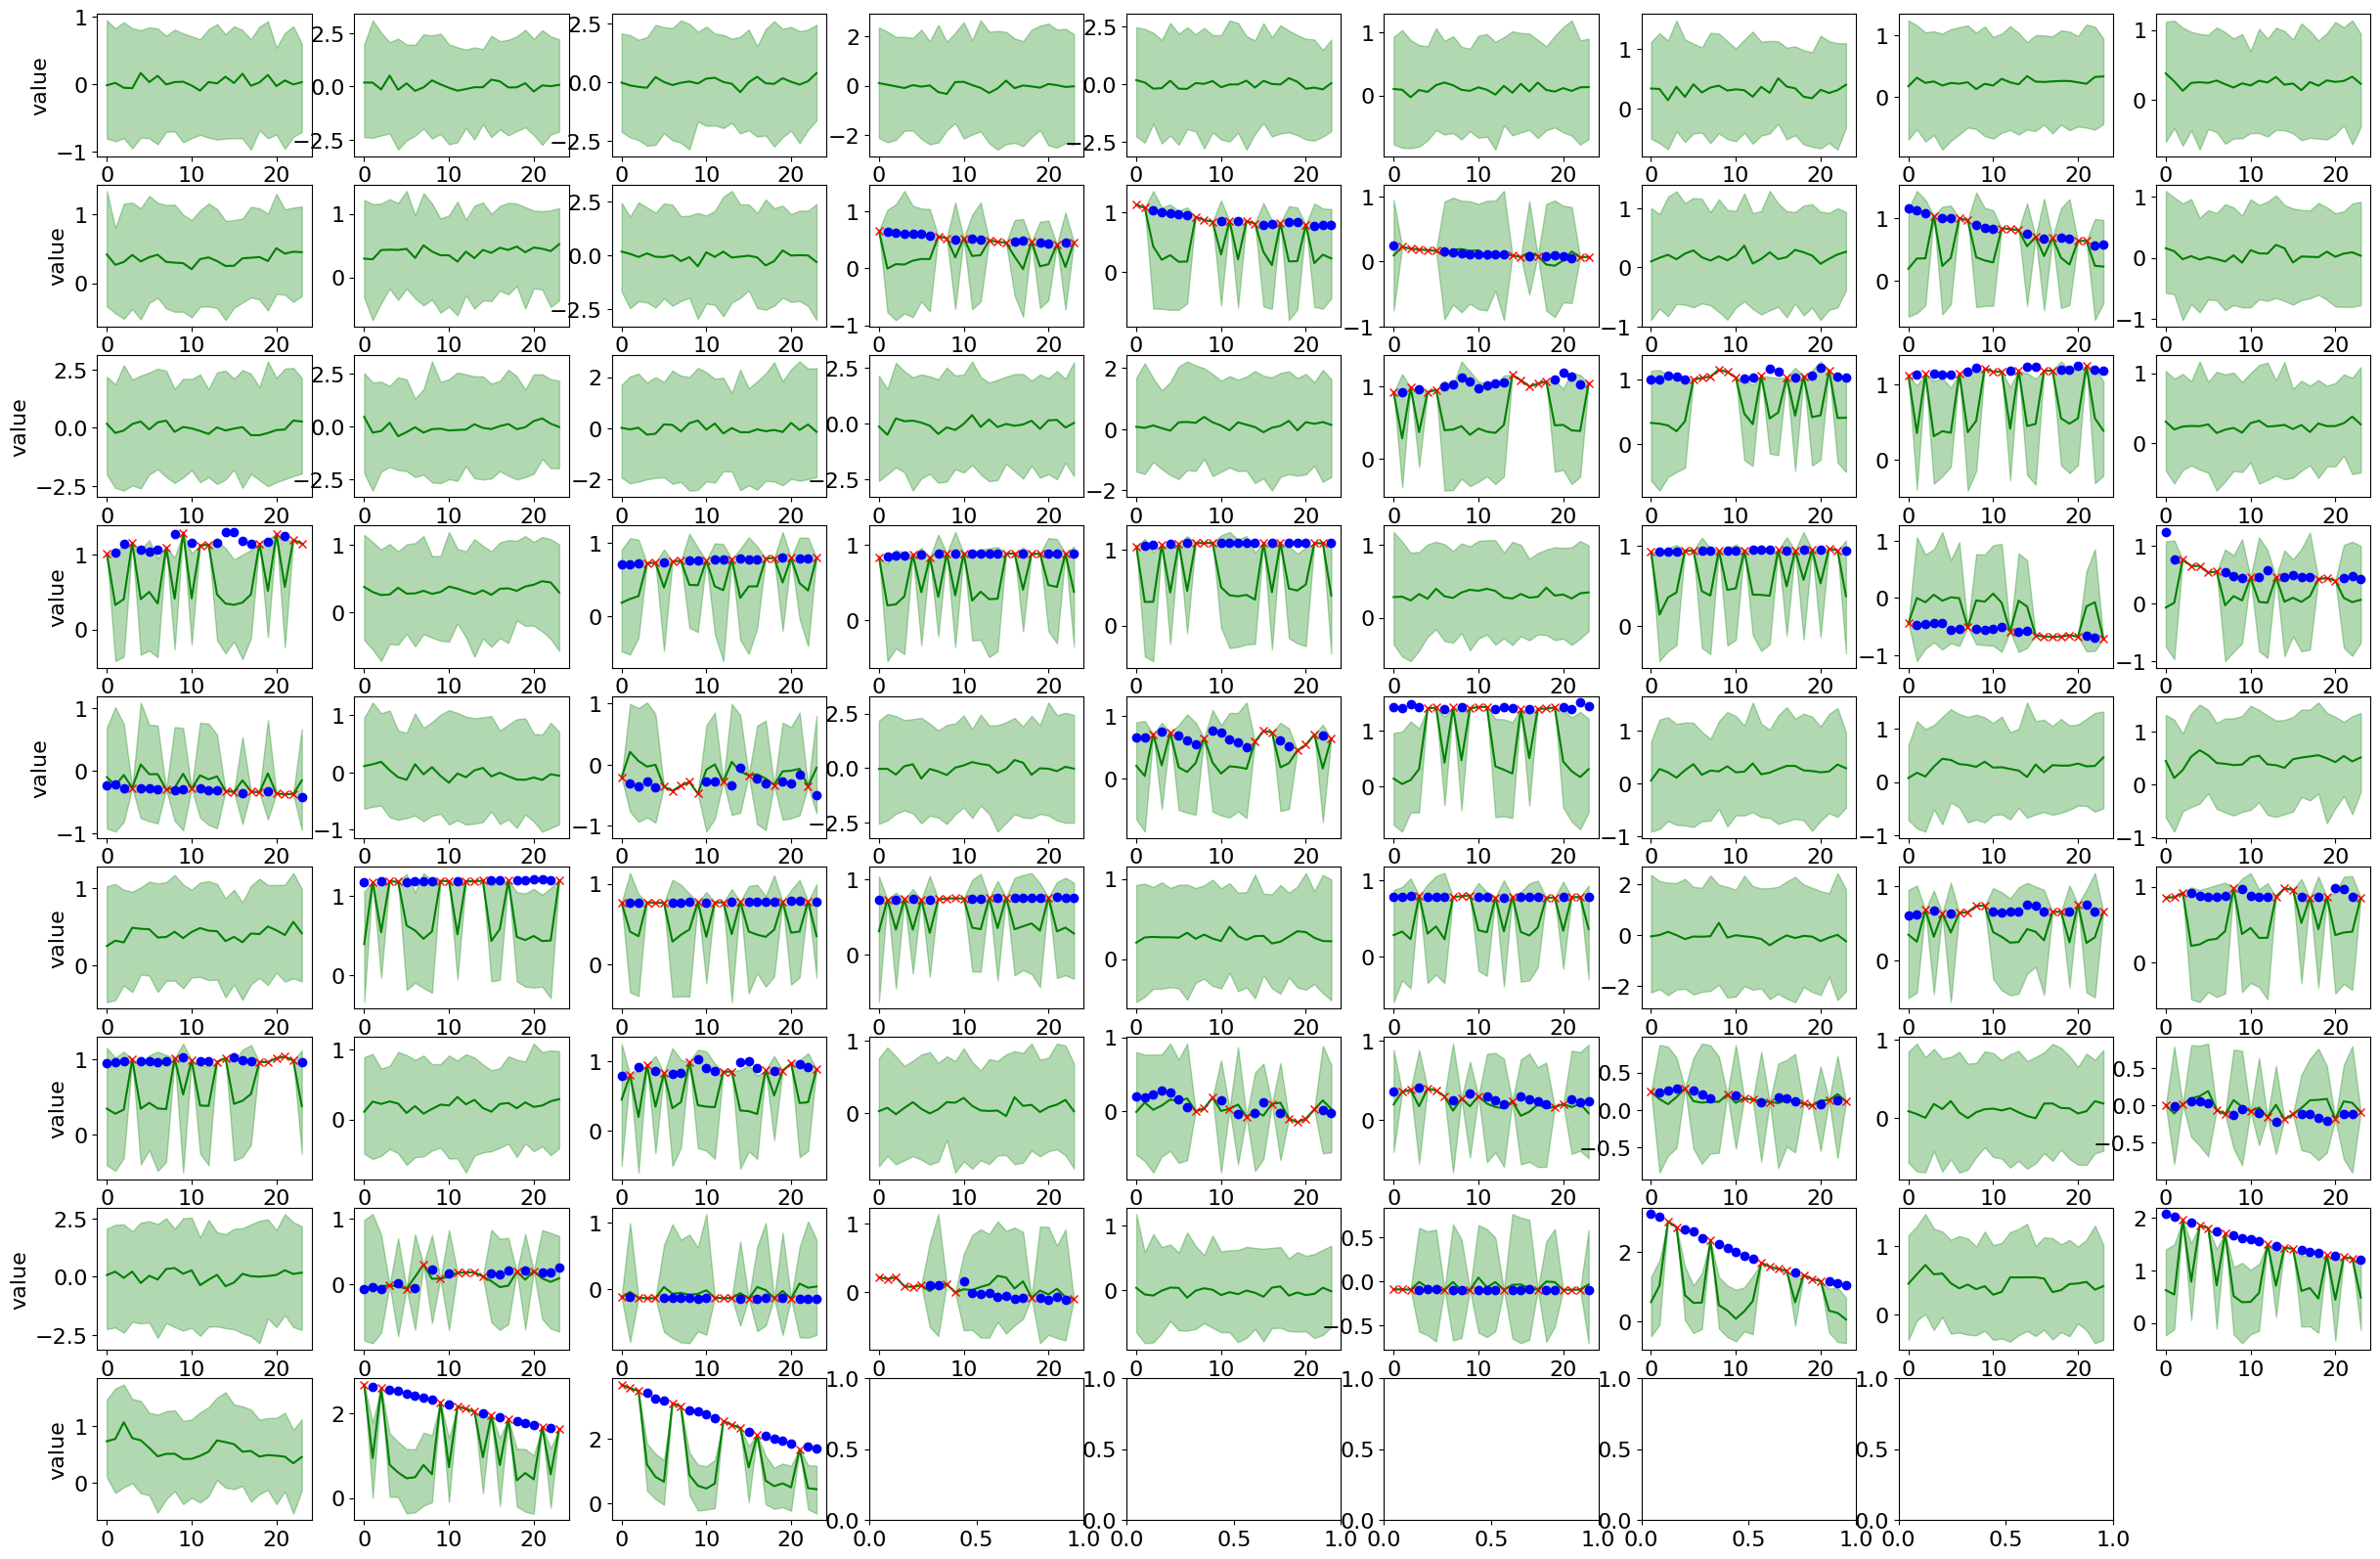

In [23]:
###airquality###
dataind = 7 #change to visualize a different sample

plt.rcParams["font.size"] = 16
fig, axes = plt.subplots(nrows=9, ncols=9,figsize=(30.0, 20.0))
fig.delaxes(axes[-1][-1])

for k in range(K):
    df = pd.DataFrame({"x":np.arange(0,L), "val":all_target_np[dataind,:,k], "y":all_evalpoint_np[dataind,:,k]})
    df = df[df.y != 0]
    df2 = pd.DataFrame({"x":np.arange(0,L), "val":all_target_np[dataind,:,k], "y":all_given_np[dataind,:,k]})
    df2 = df2[df2.y != 0]
    row = k // 9
    col = k % 9
    axes[row][col].plot(range(0,L), quantiles_imp[2][dataind,:,k], color = 'g',linestyle='solid',label='CSDI')
    axes[row][col].fill_between(range(0,L), quantiles_imp[0][dataind,:,k],quantiles_imp[4][dataind,:,k],
                    color='g', alpha=0.3)
    axes[row][col].plot(df.x,df.val, color = 'b',marker = 'o', linestyle='None')
    axes[row][col].plot(df2.x,df2.val, color = 'r',marker = 'x', linestyle='None')
    if col == 0:
        plt.setp(axes[row, 0], ylabel='value')
    if row == -1:
        plt.setp(axes[-1, col], xlabel='time')
